#Data Processing

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import cv2
from skimage import exposure
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Parameters
IMG_SIZE = 128
IMAGE_DIR = 'photos/'
MAX_IMAGES = 50000

# Load metadata
photos = pd.read_json("photos.json", lines=True)
photos = photos[photos['label'].notna()][['photo_id', 'label']]
le = LabelEncoder()
photos['label'] = le.fit_transform(photos['label'])

# Preprocessing function
def advanced_preprocess(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    img[binary == 0] = 0

    for i in range(3):
        img[:, :, i] = exposure.equalize_hist(img[:, :, i]) * 255

    img = cv2.GaussianBlur(img, (3, 3), 0)
    return img.astype(np.float32) / 255.0

# Process images
images, labels, skipped = [], [], 0
for i, row in enumerate(photos.itertuples(index=False)):
    if i >= MAX_IMAGES:
        break
    path = os.path.join(IMAGE_DIR, f"{row.photo_id}.jpg")
    try:
        img_array = advanced_preprocess(path)
        images.append(img_array)
        labels.append(row.label)
    except:
        skipped += 1
print(f"Finished processing. Skipped: {skipped}")

# Save arrays
X = np.array(images, dtype=np.float32)
y = np.array(labels)
np.save("X_images.npy", X)
np.save("y_labels.npy", y)

Finished processing. Skipped: 29


# Model Building - CNN

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Epoch 1/10


Epoch 1 - Train Loss: 0.8838 - Val Loss: 0.7006

Epoch 2/10


Epoch 2 - Train Loss: 0.6680 - Val Loss: 0.6285

Epoch 3/10


Epoch 3 - Train Loss: 0.5981 - Val Loss: 0.6345

Epoch 4/10


...

Epoch 6 - Train Loss: 0.4869 - Val Loss: 0.5257

Epoch 7/10


Epoch 7 - Train Loss: 0.4566 - Val Loss: 0.5393

Epoch 8/10


Epoch 8 - Train Loss: 0.4324 - Val Loss: 0.4997

Epoch 9/10


Epoch 9 - Train Loss: 0.4105 - Val Loss: 0.5509

Epoch 10/10


Epoch 10 - Train Loss: 0.3863 - Val Loss: 0.6523

Final Evaluation on Test Set


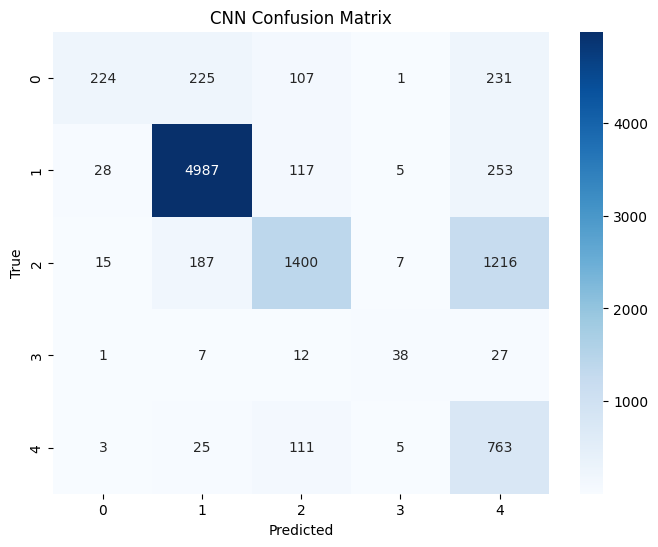

AUC Score: 0.9246


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

# Dataset class that loads images and labels lazily using memmap and indices
class MemmapDataset(Dataset):
    def __init__(self, image_path, label_path, indices):
        self.X = np.load(image_path, mmap_mode='r')
        self.y = np.load(label_path, mmap_mode='r')
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        x = self.X[i].transpose(2, 0, 1)  # Convert HWC to CHW
        y = self.y[i]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

# Load labels to get number of classes and for stratified splits
label_path = '/content/drive/MyDrive/Comp_Vis/y_labels.npy'
image_path = '/content/drive/MyDrive/Comp_Vis/X_images.npy'

all_labels = np.load(label_path, mmap_mode='r')
num_classes = len(np.unique(all_labels))

# Create train/val/test indices with stratification
full_indices = np.arange(len(all_labels))
train_idx, test_idx = train_test_split(full_indices, test_size=0.2, stratify=all_labels, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, stratify=all_labels[train_idx], random_state=42)

# Create datasets and dataloaders
train_dataset = MemmapDataset(image_path, label_path, train_idx)
val_dataset = MemmapDataset(image_path, label_path, val_idx)
test_dataset = MemmapDataset(image_path, label_path, test_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CNN model definition
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

# Evaluation function (also returns loss if requested)
def evaluate_model(model, data_loader, return_loss=False):
    model.eval()
    preds, probs, labels = [], [], []
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0
    with torch.no_grad():
        for Xb, yb in data_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            output = model(Xb)
            loss = loss_fn(output, yb)
            total_loss += loss.item()
            prob = torch.softmax(output, dim=1).cpu().numpy()
            pred = np.argmax(prob, axis=1)
            preds.extend(pred)
            probs.extend(prob)
            labels.extend(yb.cpu().numpy())

    if return_loss:
        return total_loss / len(data_loader)

    # Confusion matrix plot
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("CNN Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # AUC score
    y_true_bin = label_binarize(labels, classes=np.arange(num_classes))
    auc = roc_auc_score(y_true_bin, np.array(probs), multi_class='ovr')
    print(f"AUC Score: {auc:.4f}")

# Training function with progress bar and early stopping
def train_model(model, train_loader, val_loader, epochs=10):
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)
    criterion = nn.CrossEntropyLoss()
    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        print(f"\nEpoch {epoch+1}/{epochs}")
        for Xb, yb in tqdm(train_loader, desc="Training", leave=False):
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            output = model(Xb)
            loss = criterion(output, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_loss = evaluate_model(model, val_loader, return_loss=True)
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1} - Train Loss: {total_loss/len(train_loader):.4f} - Val Loss: {val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= 5:
            print("Early stopping triggered.")
            break

# Initialize and train model
model = ImprovedCNN(num_classes).to(device)
train_model(model, train_loader, val_loader)

# Final evaluation on test set
print("\nFinal Evaluation on Test Set")
evaluate_model(model, test_loader)

AUC Score: 0.9246